# AG-HYPOPT · Trial 09

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Eight trials. Leader: **trial_06** `cvm_fwhm` **0.0764** (sw 0.2074), then trial_05 `cvm_fwhm` 0.0777
(sw 0.2345) and trial_08 `cvm_fwhm` 0.0791 (sw 0.1816); the KDE control is **0.080328**. The three
`cvm_fwhm` points map a shallow sw minimum near 0.20-0.21. Trial_07 (KDE at sw 0.2279 -> 0.0830) ruled
out the idea that low sw alone gives the gain, so the `cvm_fwhm` edge is a loss-FORM effect. Important
caveat: every other family (`w1_2d` 0.0895, `w1_fwhm` 0.0908, `energy_2d` 0.0996, `mmd_2d` 0.1833) has
only been tested at high sw (~0.41-0.51), so whether any of them also improves at the winning sw is
unknown. No divergences. Phase `trials` (8/5), EI-guided.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_09'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (8/5 trials)
ID |     ei | params
 1 | 0.9242 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.6031481500515619}
 2 | 3.3234 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.22840352954234588}
 3 | 3.3221 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.22918956498737353}
 4 | 2.4857 | {"loss_family": "mmd_2d", "sigma_weight": 0.22659098170950503}
 5 | 2.0347 | {"loss_family": "kde", "sigma_weight": 0.2456576194743361}
 6 | 2.0421 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.7053337045894538}
 7 | 2.4812 | {"loss_family": "energy_2d", "sigma_weight": 0.22913547212389987}
 8 | 1.1791 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.2661253232167806}
 9 |      - | {"loss_family": "kde", "sigma_weight": 0.9128100517839179}
10 |      - | {"loss_family": "cvm_fwhm", "sigma_weight": 0.7082069141031725}


## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

The batch is dominated by `cvm_fwhm` at sw ~0.23-0.27 (candidates 2, 3, 8, plus high-sw 1, 6, 10).
Candidates 2 and 3 (sw 0.2284 / 0.2292, ei ~3.32) merely sit on trial_05's sw and would re-confirm
~0.0777; that is low information now that trial_08 has already bracketed the minimum. The genuinely
open question is whether the `cvm_fwhm` lead is unique to that family: `w1_2d`, `energy_2d` and `mmd_2d`
were only ever run at high sw and could improve sharply at the winning sw (exactly as `cvm_fwhm`
appears to prefer ~0.21). KDE has already been checked at low sw (0.0830), so it is less informative
now.

Scanning the table: candidate 7 is `energy_2d` at sw 0.2291 (ei 2.4812) - the best-ranked non-`cvm_fwhm`
S-D family, placed right at the winning sw, which directly tests whether the energy distance competes
once its sigma channel is dialled to the same level. (No `w1_2d` draw appears in this batch;
`mmd_2d` - candidate 4 - is the weakest family and lower priority.)

I choose candidate 7.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 7             # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'loss_family': 'energy_2d', 'sigma_weight': 0.22913547212389987}
Running  1nW Trans05 ... 

μ 9.39 -> 6.24 | γ 8.5 -> 2.33 | NLL 44.14


Running  1nW Trans20 ... 

μ 17.32 -> 26.10 | γ 8.5 -> 5.18 | NLL 6.07


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 60.74 | γ 14.1 -> 13.90 | NLL 5.11


Running 3nW Trans100 ... 

μ 175.71 -> 95.55 | γ 14.1 -> 13.49 | NLL 4.24



Total: 7.7 min


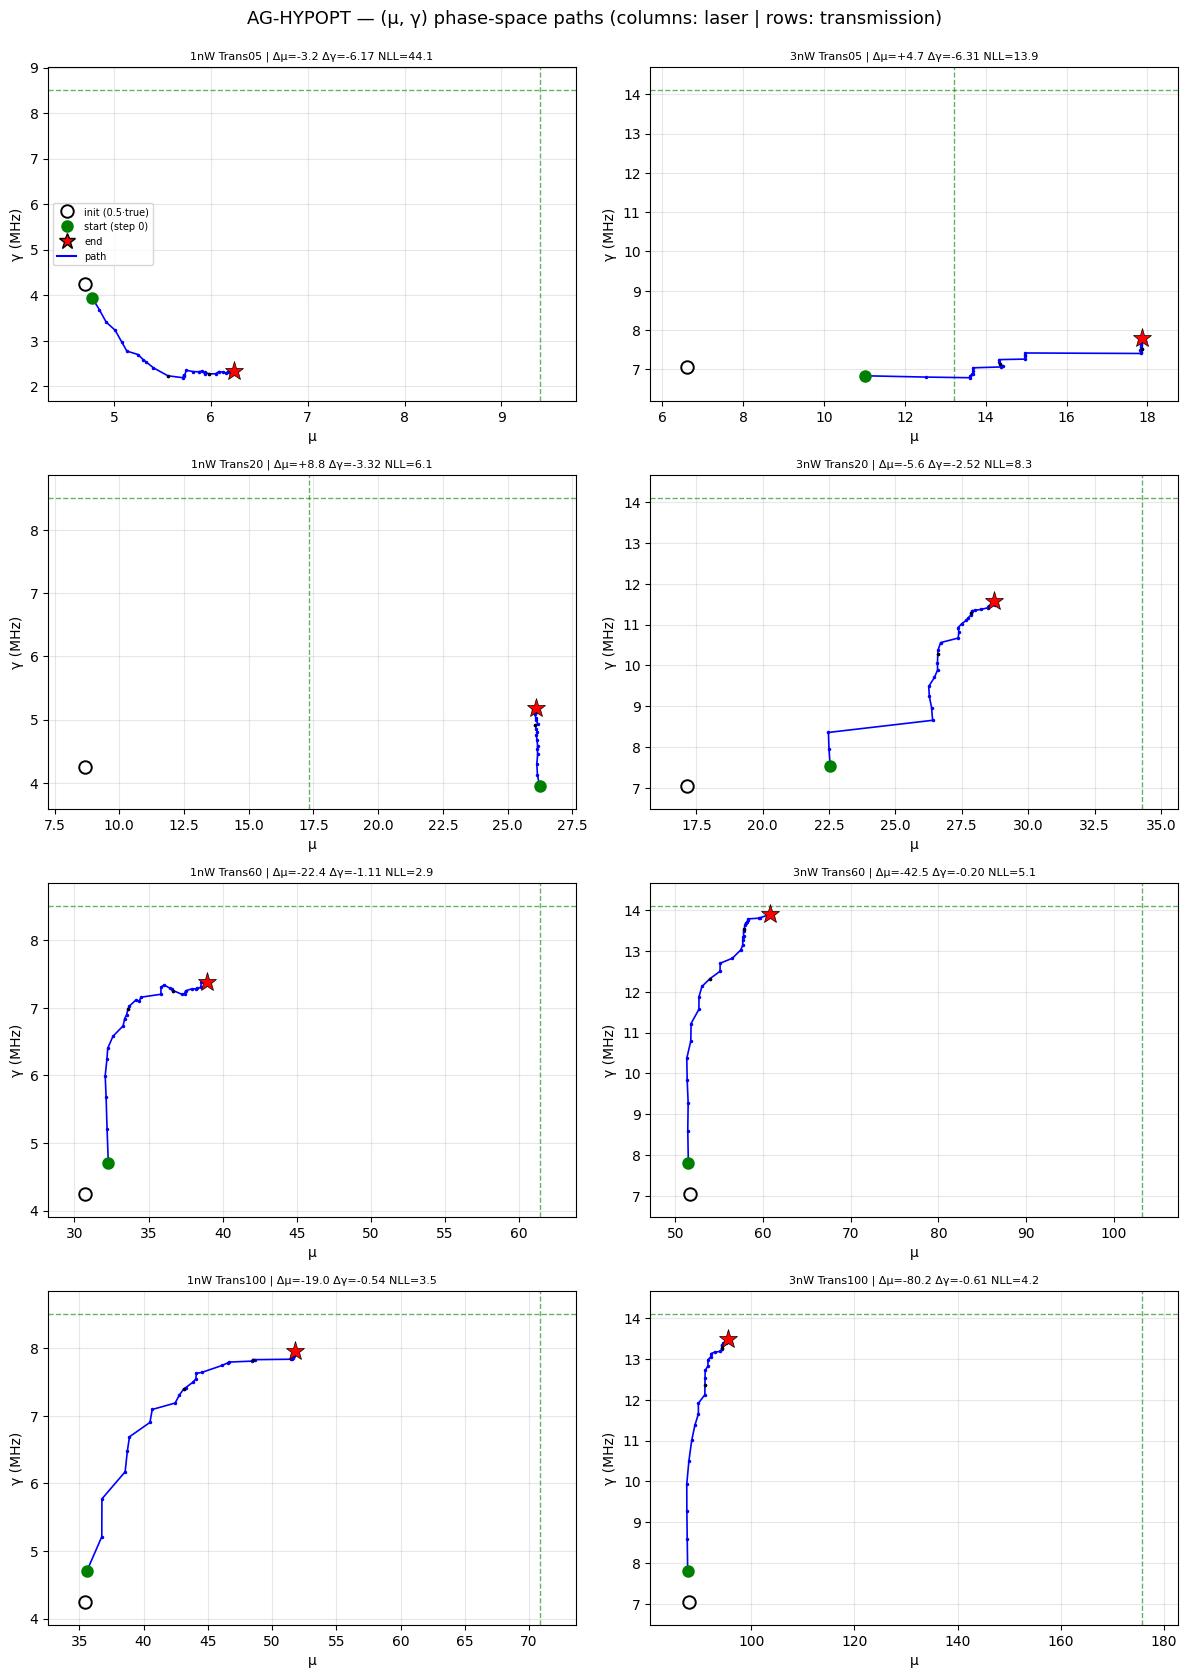

trial finished in 7.8 min
objective = 0.1021 ± 0.0337
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    6.24   -33.6 |     8.50    2.33   -72.6
1nW Trans20       17.32   26.10   +50.7 |     8.50    5.18   -39.1
1nW Trans60       61.37   38.97   -36.5 |     8.50    7.39   -13.1
1nW Trans100       70.82   51.80   -26.9 |     8.50    7.96    -6.4
3nW Trans05       13.20   17.86   +35.3 |    14.10    7.79   -44.8
3nW Trans20       34.28   28.72   -16.2 |    14.10   11.58   -17.9
3nW Trans60      103.20   60.74   -41.1 |    14.10   13.90    -1.4
3nW Trans100      175.71   95.55   -45.6 |    14.10   13.49    -4.4

weighted objective (T-graded, cap=1.0) = 0.1021 | diverged cells: 0
μ: RMSE 33.969 (rel 37.1%, bias -19.914) | γ: RMSE 3.486 (rel 34.2%, bias -2.599)


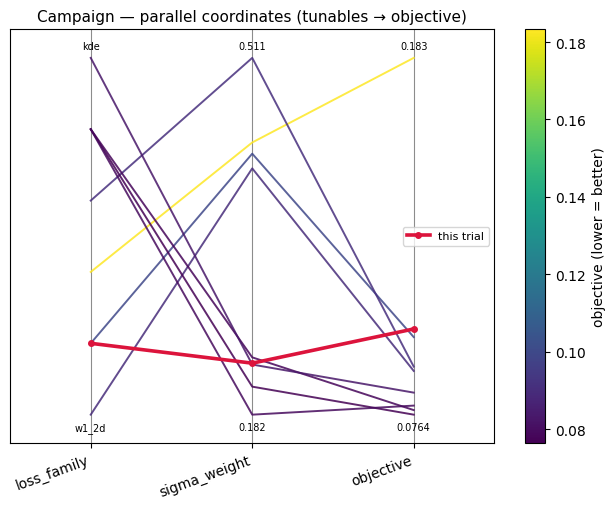

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

**Facts.** Chosen config `{loss_family: 'energy_2d', sigma_weight: 0.2291}` (candidate 7). Trial
time 7.8 min, objective **0.1021 +/- 0.0337**, **0 diverged cells**. This places `energy_2d` at the
winning sw and it does **not** improve: at sw 0.4228 it was 0.0996, here at sw 0.2291 it is 0.1021. So
the low-sw region that helps `cvm_fwhm` does nothing for the energy distance.

**Per-cell behaviour.**

- 1nW Trans05: mu -33.6 %, gamma 8.5 -> 2.33 (*** -72.6 % ***) - the worst low-count gamma of the whole
  campaign, far under `cvm_fwhm`'s -50 %.
- 1nW Trans20: mu +50.7 %, gamma -39.1 %.
- 1nW Trans60 / Trans100: mu -36.5 % / -26.9 %, gamma -13.1 % / -6.4 %.
- 3nW Trans05 / Trans20: mu +35.3 % / -16.2 %, gamma -44.8 % / -17.9 %.
- 3nW Trans60 / Trans100: mu -41.1 % / -45.6 %, gamma -1.4 % / -4.4 %.

**Aggregates.** mu: RMSE 33.97 (rel 37.1 %), bias -19.91; gamma: RMSE 3.49 (rel 34.2 %), bias -2.60 -
gamma the worst of the campaign so far, tied with trial_03's 3.55. So the energy form's failure is mainly
the gamma channel, and it is not a sw issue.

**Summary:** `energy_2d` at the winning sw (0.2291) gives objective 0.1021, no better than its high-sw
value (0.0996) and clearly behind `cvm_fwhm` (0.0764), with the campaign's worst low-count gamma.
**Key insight:** The low-sw gain is specific to the `cvm_fwhm` loss form; the energy distance does not
benefit from it, so the family ranking is not a `sigma_weight` artitact.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
[Notes for Anuar: none - loss-FORM comparison inside the pre-authorized knob.]


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'energy_2d at the winning sigma_weight (0.2291) gives objective 0.1021, no better than its high-sw value (0.0996) and clearly behind cvm_fwhm (0.0764), with the worst low-count gamma of the campaign.'      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = 'The low-sw gain is specific to the cvm_fwhm loss form; the energy distance does not benefit from it, so the family ranking is not a sigma_weight artifact.'  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_09 | current best: trial_06


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_10.ipynb. Open it and follow its cells from the top.
